<a href="https://colab.research.google.com/github/ohta-ee-ous/Lecture_ImageProcessing/blob/main/%E7%94%BB%E5%83%8F%E5%87%A6%E7%90%86%E6%BC%94%E7%BF%92_3_%E7%A9%BA%E9%96%93%E3%83%95%E3%82%A3%E3%83%AB%E3%82%BF%E3%83%AA%E3%83%B3%E3%82%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
デジタル画像処理演習

# **空間フィルタリング**

2026/04/27 改訂

---

この演習では、空間フィルタリングに関して次の内容を学習します。
1. 画像の平滑化
1. 画像の微分
1. 画像の鮮鋭化

次に書かれている「準備」から順番に進めていってください。  

最後に[課題](#assignment)があります。

<a name="junbi"></a>
# **準備**

最初に準備を行います。次のコードを実行してください。

In [ ]:
#@title ⌨ 準備
# 外部モジュールを取り込む
import cv2
import numpy as np
from google.colab import output
from google.colab.patches import cv2_imshow

# ユーザーのディスプレイの解像度に合わせて画像の画面表示サイズを調整する
screen_resolution = output.eval_js('[window.screen.width, window.screen.height, screen.orientation.type]')
screen_scale = max(screen_resolution[:2])/1920
def show_image(img):
  if screen_scale >= 1.0:
    cv2_imshow(img)
  else:
    cv2_imshow(cv2.resize(img, None, fx=screen_scale, fy=screen_scale))

# 使用するデータをダウンロードする。
!wget -nc "https://github.com/ohta-ee-ous/Lecture_ImageProcessing/releases/download/v1.0.0/imagefiles.zip" -O imagefiles.zip
!unzip -nq imagefiles.zip
!rm -f imagefiles.zip
!if [[ -f "asagao.png" && -f "README.txt" ]]; then echo "準備が完了しました。"; else echo "ファイルが準備できませんでした。"; fi

「準備が完了しました。」と表示されれば成功です。
次のライブラリや関数が使えるようになっています。

|名称|説明|
|:---|:---|
|cv2|画像処理ライブラリ OpenCV|
|np|数値計算ライブラリ NumPy|
|cv2_imshow|Colab専用の画像表示関数|

画像ファイルも用意されています。Colab の画面の左端にある「ファイル」アイコン（📁の形）をクリックするとファイルブラウザが表示されて、ファイルの一覧を見ることができます。もう一度クリックすると非表示になります。  
自分のパソコンに保存してある画像ファイルを Colab で使いたい場合には、このファイルブラウザの中へ画像ファイルをドラッグ＆ドロップしてください。

<br>

# **1．画像の平滑化**

画像の平滑化を行う空間フィルタには、

- 移動平均フィルタ
- 加重平均フィルタ
- ガウシアンフィルタ
- メディアンフィルタ
- バイラテラルフィルタ
- ノンローカルミーンフィルタ

などがあります。これらを順に試していきましょう。

## ノイズのある画像の作成

平滑化の効果を見るためにノイズのある画像を用意します。  
まず、もとになる原画像を読み込みます。次のコードを実行してください。

In [ ]:
#@title ⌨ 原画像の読み込み
src = cv2.imread('asagao.png')
show_image(src)

この画像にノイズをランダムに加えます。作成した画像は、変数`noisyimg` に記憶します。  
次のコードを実行して、画像にノイズが付いていることを確かめてください。

In [ ]:
#@title ⌨ 画像にノイズを付加する
noisyimg = src.copy() # noisyimgにsrcのコピーをとる
noise = np.random.normal(0, 30, src.shape).astype(np.float32) # 正規分布でノイズをランダムに生成
mask = np.random.randint(0, 2, src.shape).astype(np.float32)  # ノイズを付加する画素をランダムに選択
noisyimg = np.clip(noisyimg+noise*mask, 0, 255).astype(np.uint8) # ノイズを付加した画像を生成
cv2.imwrite('NoisyImage.png', noisyimg) # 画像を保存
cv2_imshow(noisyimg)

ざらついた画像になりましたね。
この画像は「`NoisyImage.png`」というファイル名で保存しています。  

この後の演習で変換前と変換後の画像の比較がしやすいように、この画像をColabの別タブ（ペイン）に表示しておきましょう。  
Colabの画面の左端にあるファイルアイコン（📁）をクリックしてファイルブラウザを開き、その中にある「`NoisyImage.png`」をダブルクリックしてください。ファイルがない場合は、更新アイコンをクリックしてみてください。Colabの画面の右側に画像が表示されます。

## 移動平均フィルタ

OpenCVで移動平均フィルタをかける場合は、`cv2.blur`関数を使用します。

<h3>使い方</h3>

*dst* = <tt>cv2.blur</tt>( *src*, *ksize* )

- *src* : 入力画像の変数を与える。
- *ksize* : フィルタのサイズを与える。(*横幅*, *縦幅*) の形で指定する。
- *dst* : 出力画像の変数を与える。


次のコードではフィルタサイズを 3x3（横幅3、縦幅3）にしています。コードを実行して移動平均フィルタの結果を見てください。

In [ ]:
#@title ⌨ 移動平均フィルタ
dst = cv2.blur(noisyimg, (3, 3))
show_image(dst)

画像がぼやけることで、ノイズがやや低減していますね。

### ✍ 実戦問題 1

cv2.blur関数に与えているフィルタのサイズの値を`(3, 3)`から別の値に変えて、変換後の画像の変化を見てみましょう。  
下のコードを次のように変えてください。

1. `(11, 11)`にしてみよう。
1. もっと大きな数字にしてみよう。
1. `(30, 1)`にしてみよう。どのような画像になりましたか？


<details><summary>答え</summary>

1. `dst = cv2.blur(noisyimg, (11, 11))`
1. 例えば、`dst = cv2.blur(noisyimg, (51, 51))`
1. `dst = cv2.blur(noisyimg, (30, 1))`  
横1列にある30個の画素の画素値の平均値になるため横方向にだけぼかしがk掛かって、横にブレたような画像になります。

</details>

In [ ]:
#@title ⌨ 実践問題用コード 1
dst = cv2.blur(noisyimg, (3, 3))
show_image(dst)

## 空間フィルタを自作する

`cv2.filter2D`関数を使うと、自分で設計した空間フィルタで画像のフィルタリング（畳み込み演算）を行うことができます。

<h3>使い方</h3>

*dst* = <tt>cv2.filter2D</tt>( *src*, *ddpeth*, *kernel* )

- *src* : 入力画像の変数を与える。
- *ddepth* : 出力画像の深度（データ型）を与える。通常は -1 でよい（入力画像と同じにするという指定）。


  - <tt>cv2.CV_16S</tt> : 符号付き 16 bit 整数
  - <tt>cv2.CV_8U</tt> : 符号無し 8 bit 整数
  - <tt>cv2.CV_32F</tt> : 32 bit 実数

- *kernel* : フィルタの変数を与える。
- *dst* : 出力画像の変数を与える。

`cv2.filter2D`関数を使って画像 noisyimg に 3x3のサイズの移動平均フィルタをかけてみましょう。

まず、移動平均フィルタのカーネル（フィルタ係数からなる行列）を変数に設定します。設定する値は次のとおりです。

$$\begin{bmatrix}
1/9 & 1/9 & 1/9\\
1/9 & 1/9 & 1/9\\
1/9 & 1/9 & 1/9
\end{bmatrix}$$


下のコードでは、`kernel`という変数に設定し、この `kernel` と `noisyimg` を `cv2.filter2D`関数に与えています。

コードを実行して結果を確認してください。

In [ ]:
#@title ⌨ 空間フィルタの設計とフィルタ処理
# カーネルの定義（3x3のサイズ）
kernel = [ 1/9,  1/9,  1/9,
           1/9,  1/9,  1/9,
           1/9,  1/9,  1/9, ]
kernel = np.array(kernel).reshape(3, 3)  # kernelを3行3列の2次元配列に変換する

# kernelによってnoisyimgにフィルタリング（畳み込み演算）を行う
dst = cv2.filter2D(noisyimg, -1, kernel)
show_image(dst)

表示される画像は、`cv2.blur(noisyimg, (3, 3))`を実行した場合と同じになります。

## 加重平均フィルタ

加重平均フィルタは `cv2.filter2D`関数を使ってつくります。

### ✍ 実践問題 2

下記のカーネルをもつ加重平均フィルタを作成しましょう。

$$\begin{bmatrix}
1/16 & 2/16 & 1/16\\
2/16 & 4/16 & 2/16\\
1/16 & 2/16 & 1/16
\end{bmatrix}$$

次のコードの変数 `kernel`を加重平均フィルタのカーネルに書き換えて実行してください。

カーネルの中の係数をいろいろと変えて試してみましょう。

<details><summary>答え</summary>

```
kernel = [ 1/16,  2/16,  1/16,
           2/16,  4/16,  2/16,
           1/16,  2/16,  1/16, ]
kernel = np.array(kernel).reshape(3, 3)
dst = cv2.filter2D(noisyimg, -1, kernel)
show_image(dst)
```
</details>

In [ ]:
#@title ⌨ 実践問題用コード 2
kernel = [ 1/9,  1/9,  1/9,
           1/9,  1/9,  1/9,
           1/9,  1/9,  1/9, ]
kernel = np.array(kernel).reshape(3, 3)
dst = cv2.filter2D(noisyimg, -1, kernel)
show_image(dst)

## ガウシアンフィルタ

ガウシアンフィルタをかける場合は `cv2.GaussianBlur`関数を使用します。

ガウシアンフィルタのカーネルの係数は一般に次の式で表されます。
$$G(x,y)=\frac{1}{2\pi\sigma^2}\exp\left(-\frac{x^2+y^2}{2\sigma^2}\right)$$
カーネルの中心は、$(x,y)=(0,0)$です。

<h3>使い方</h3>

*dst* = <tt>cv2.GaussianBlur</tt>( *src*, *ksize*, *sigmaX*, *dst*, *sigmaY* )

- *src* : 入力画像の変数を与える。
- *ksize* : フィルタのサイズを与える。(*横幅*, *縦幅*) の形で指定する。奇数で指定しなければならない。*sigmaX*, *sigmaY*の方でサイズを指定する場合は`None`を与える。
- *sigmaX* : 2次元正規分布の横方向の標準偏差を与える。0を指定した場合は*ksize*の値から自動で決まる。
- *sigmaY* : 2次元正規分布の縦方向の標準偏差を与える。0を指定したときは*sigmaX*と同じになる。
- *dst* : 出力画像の変数を与える。

次のコードでは標準偏差を 2 にしています。コードを実行して結果を確認してください。

In [ ]:
#@title ⌨ ガウシアンフィルタ
dst = cv2.GaussianBlur(noisyimg, None, 2)
show_image(dst)

標準偏差の値 2 を別の値に変えて、結果を見比べてみましょう。

## メディアンフィルタ

画像にメディアンフィルタをかけるには `cv2.medianBlur`関数を使用します。

メディアンフィルタは非線形フィルタの一種で、指定範囲内の中央値（メディアン）を求めて変換後の画素値とします。したがって、これまでのフィルタのようなフィルタ係数からなるカーネルはありません。

<h4>使い方</h4>

*dst* = <tt>cv2.medianBlur</tt>( *src*, *ksize* )

- *src* : 入力画像の変数を与える。
- *ksize* : フィルタのサイズを与える。**奇数**を指定しなければならない。縦幅と横幅は同じになる。
- *dst* : 出力画像の変数を与える。


次のコードを実行して、メディアンフィルタの結果を確かめてください。

In [ ]:
#@title ⌨ メディアンフィルタ
dst = cv2.medianBlur(noisyimg, 3)
show_image(dst)

移動平均フィルタや加重平均フィルタと比べると、エッジがあまりぼやけずにノイズ除去ができていますね。

## バイラテラルフィルタ

バイラテラルフィルタは、メディアンフィルタと同じように画像のエッジを保存する平滑化フィルタの一種です。  
バイラテラルフィルタをかけるには、`cv2.bilateralFilter`関数を使用します。

<h4>使い方</h4>

*dst* = <tt>cv2.bilateralFilter</tt>( *src*, *d*, *sigmaColor*, *sigmaSpace* )

- *src* : 入力画像の変数を与える。
- *d* : フィルタのサイズ（直径）を与える。
- *sigmaColor* : 画素値における標準偏差を与える。
- *sigmaSpace* : 座標空間における標準偏差を与える。
- *dst* : 出力画像の変数を与える。

次のコードを実行して、バイラテラルフィルタの結果を確かめてください。

In [ ]:
#@title ⌨ バイラテラルフィルタ
dst = cv2.bilateralFilter(noisyimg, 10, 80, 30)
show_image(dst)

ノイズが綺麗に消えていまね。さらに、エッジ部分がしっかりと残ったまま、花びらや葉の表面が滑らかになっているように見えます。

## ノンローカルミーンフィルタ

ノンローカルミーンバフィルタも、画像のエッジを保存する平滑化フィルタの一種です。  
ノンローカルミーンバフィルタをかけるには、`cv2.fastNlMeansDenoising`関数を使用します。

<h4>使い方</h4>

*dst* = cv2.fastNlMeansDenoising( *src*, *h*, *templateWindowSize*, *searchWindowSize* )

- *src* : 入力画像の変数を与える。
- *h* : フィルタの強度を与える。
- *templateWindowSize* : テンプレートのサイズを与える。
- *searchWindowSize* : 検索ウインドウサイズを与える。
- *dst* : 出力画像の変数を与える。

次のコードを実行して、ノンローカルミーンフィルタの結果を確かめてください。

In [ ]:
#@title ⌨ ノンローカルミーンフィルタ
dst = cv2.fastNlMeansDenoising(noisyimg.astype(np.uint8), 3, 21, 9)
show_image(dst)

ノンローカルミーンフィルタは強力なノイズ除去ができますが、その反面、計算量が多いという欠点があります。

<br>

# **2．画像の微分**

次に、画像の微分を見ていきましょう。  

微分とは、簡単に言うと、連続しているデータのある点における変化の量です。
画像データの場合では、隣り合う画素どうしの画素値の差になります。

## 画像の読み込み

まず、ここで使う画像を読み込みます。今回は結果を見やすくするためにグレイスケール画像を用います。  
次のコードを実行してください。

In [ ]:
#@title ⌨ 画像の読み込み
src = cv2.imread('house.png')
gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY) # グレイスケールに変換
show_image(gray)

## 1次微分

デジタル画像において横方向（$x$軸方向）の1次微分は、
$$\frac{\partial}{\partial x}f(x,y)=f(x+1,y)-f(x,y)$$
で計算されます。

これを空間フィルタのカーネルで表すと次のようになります。
$$\begin{bmatrix}
0 & 0 & 0\\
0 & -1 & 1\\
0 & 0 & 0
\end{bmatrix}$$

`cv2.filter2D`関数を使って実装すると、下のようなコードになります。

微分値は負の値になる場合あり、そのままでは画素値として使えないため、`np.abs`関数を用いて絶対値に変換してから表示しています。

In [ ]:
#@title ⌨ 横方向の微分
kernel = [ 0,   0,  0,
           0,  -1,  1,
           0,   0,  0, ]
kernel = np.array(kernel).reshape(3, 3)
dst = cv2.filter2D(gray, cv2.CV_32F, kernel)
show_image(np.abs(dst))

左右の隣り合う画素の画素値の差が大きいほど白くなります。横方向の微分を行うと、画像の縦向きのエッジが抽出できます。

## ✍ 実践問題 3

それでは、同じようにして、縦方向の1次微分を行いましょう。
縦方向（$y$軸方向）の1次微分は次の式になります。
$$\frac{\partial}{\partial y}f(x,y)=f(x,y+1)-f(x,y)$$

次のコードが縦方向の1次微分になるように、`kernel`の値を書き換えてから実行してください。

画像の横向きのエッジが抽出されれば成功です。

<details>
<summary>答え</summary>

```
kernel = [ 0,   0,  0,
           0,  -1,  0,
           0,   1,  0, ]
kernel = np.array(kernel).reshape(3, 3)
dst = cv2.filter2D(gray, cv2.CV_32F, kernel)
cv2_imshow(np.abs(dst))
```
</details>


In [ ]:
#@title ⌨ 実践問題用コード 3
kernel = [ 0,   0,  0,
           0,  -1,  1,
           0,   0,  0, ]
kernel = np.array(kernel).reshape(3, 3)
dst = cv2.filter2D(gray, cv2.CV_32F, kernel)
show_image(np.abs(dst))

## ソーベルフィルタ

ソーベルフィルタは、次のカーネルで1次微分を行うフィルタです。
$$\mathrm{横方向の微分}=\begin{bmatrix}
-1 & 0 & 1\\
-2 & 0 & 2\\
-1 & 0 & 1
\end{bmatrix},~~~~\mathrm{縦方向の微分}=\begin{bmatrix}
-1 & -2 & -1\\
 0 & 0 & 0\\
 1 & 2 & 1
\end{bmatrix}$$

ソーベルフィルタは`cv2.Sobel`関数で行うことができます。

<h4>使い方</h4>

*dst* = <tt>cv2.Sobel</tt>( *src*, *ddepth*, *dx*, *dy* )

- *src* : 入力画像の変数を与える。
- *ddepth* : 出力画像の深度（データ型）を与える。


  - <tt>cv2.CV_16S</tt> : 符号付き 16 bit 整数
  - <tt>cv2.CV_8U</tt> : 符号無し 8 bit 整数
  - <tt>cv2.CV_32F</tt> : 32 bit 実数

- *dx* : 横方向の微分次数を与える。
- *dy* : 縦方向の微分次数を与える。
- *dst* : 出力画像の変数を与える。
- 横方向の微分の場合は *dx*=1, *dy=0*、縦方向の微分の場合は *dx*=0, *dy*=1 を与える。

次のコードを実行して、ソーベルフィルタの結果を確かめてください。  
横方向の微分の結果は変数`sobel_x`に、縦方向の微分の結果は変数`sobel_y`に代入されます。結果の画像は`np.abs`関数で絶対値に変換してから表示しています。

In [ ]:
#@title ⌨ ソーベルフィルタ
sobel_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0) # 横方向のソーベルフィルタ
sobel_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1) # 縦方向のソーベルフィルタ
print('横方向のソーベルフィルタ')
show_image(np.abs(sobel_x))
print('\n縦方向のソーベルフィルタ')
show_image(np.abs(sobel_y))

## エッジ強度

次の式で、横方向と縦方向の微分値からエッジ強度が計算できます。

$$\sqrt{\left(\frac{\partial}{\partial x}f(x,y)\right)^2+\left(\frac{\partial}{\partial y}f(x,y)\right)^2}$$

これをコードにすると次のようになります。コードを実行してください。

In [ ]:
#@title ⌨ エッジ強度
dst = np.sqrt(sobel_x**2 + sobel_y**2)
show_image(dst)

横方向と縦方向の微分の結果を合成して画像にすることができます。

このように、画像の微分によって画像内のエッジを検出することができます。

## エンボス効果

平らな素材に型を押し付けて表面に凹凸の模様をつけることをエンボス加工といいます。  
斜め方向の微分を利用すると、エンボス加工のような画像変換ができます。

斜め方向の微分の空間フィルタのカーネルは次のように定義できます。

$$\begin{bmatrix}
-2 & -1 & 0\\
-1 & 0 & 1\\
0 & 1 & 2
\end{bmatrix}$$

この微分の結果の画像に 128 を加算すると、エンボス加工のような画像になります。  
次のコードを実行してください。

In [ ]:
#@title ⌨ エンボス効果
filter = [ -2, -1,  0,
           -1,  0,  1,
            0,  1,  2, ]
filter = np.array(filter).reshape(3, 3)
diag = cv2.filter2D(gray, cv2.CV_32F, filter) # 斜め方向に微分
dst = diag + 128 # 128 を加算
show_image(dst)

灰色の背景に凹凸がついたような立体感のある画像ができましたね。

## ラプラシアンフィルタ

次は、画像の2次微分を見てみましょう。2次微分の式は次のようになります。

$$\frac{\partial^2}{\partial x^2}f(x,y)=f(x-1,y)-2f(x,y)+f(x+1,y)$$

$$\frac{\partial^2}{\partial y^2}f(x,y)=f(x,y-1)-2f(x,y)+f(x,y+1)$$


これからラプラシアンは次のように定義されます。
$$\begin{align}
\nabla^2 f(x,y) &= \frac{\partial^2}{\partial x^2}f(x,y) + \frac{\partial^2}{\partial y^2}f(x,y)\\[4pt]
&= f(x,y-1)+f(x-1,y)-4f(x,y)+f(x+1,y)+f(x,y+1)
\end{align}$$

これより、ラプラシアンフィルタのカーネルは次のようになります。
$$\begin{bmatrix}
0 & 1 & 0\\
1 & -4 & 1\\
0 & 1 & 0
\end{bmatrix}$$

画像にラプラシアンフィルタをかけるには `cv2.Laplacian`関数を使用します。

<h4>使い方</h4>

*dst* = <tt>cv2.Laplacian</tt>( *src*, *ddepth* )

- *src* : 入力画像の変数を与える。
- *ddepth* : 出力画像の深度（データ型）を与える。
- *dst* : 出力画像の変数を与える。

次のコードを実行して、ラプラシアンフィルタの結果を確かめてください。

In [ ]:
#@title ⌨ ラプラシアンフィルタ
lap = cv2.Laplacian(gray, cv2.CV_32F)
show_image(np.abs(lap))

ラプラシアンは横方向と縦方向の2次微分の結果を足し合わせるものなので、このように、縦と横のエッジが同時に抽出されます。

<br>

# **3．画像の鮮鋭化**

## ラプラシアンフィルタを利用した鮮鋭化

画像にラプラシアンフィルタをかけた結果を、元の画像から引き算することで、画像の鮮鋭化ができます。

まず、Colabのファイルブラウザで、原画像の「house.png」のファイルを開いてください。  
次のコードを実行して、結果を原画像と比較してください。

In [ ]:
#@title ⌨ 鮮鋭化
lap = cv2.Laplacian(src, cv2.CV_32F)
dst = src - lap # 画像からラプラシアンフィルタの結果を引き算する
show_image(dst)

## ✍ 実践問題 4

原画像から引き算するラプラシアンの値を大きくするほど、鮮鋭化の度合いが大きくなります。

次のコードの変数`src`には原画像、変数`lap`には前のコードで得られたラプラシアンの値が代入されています。

1. `lap`の値を3倍にすると画像がどうなるのか確認しよう。
1. `lap`の値を5倍にすると、画像中の窓や玄関のドアのところに白色の枠線が現れます。これは何故でしょうか？

<details>
<summary>答え</summary>

1. `dst = src - lap*3`  
鮮鋭化がより強まる。建物の表面のざらつきまでよく見えるようになる。
1. `dst = src - lap*5`  
もともとエッジ強度が高いところが鮮鋭化されると、明るいところはより明るく（オーバーシュート）、暗いところはより暗く（アンダーシュート）なる現象が起こる。これによって、窓やドアのエッジ部分が極端に明るい白、または、極端に暗い黒になる。

</details>


In [ ]:
#@title ⌨ 実践問題用コード 4
dst = src - lap*3
show_image(dst)

以上で演習は終了です。

以下は課題の問題です。



---

<a name="assignment"></a>
# **4．課題**

## 画像の準備

自分で用意した画像を使う場合は、次の手順で準備を行ってください。

1. 画像ファイルを用意して、Colab のファイルブラウザにアップロードする。
1. アップロードしたファイルの名前を次のコードの中に書く。ファイル拡張子（.jpgなど）も書くこと。
1. コードを実行する。  


このコードでは、元の画像のサイズが大きい場合（横幅 480画素以上）、横幅が 480 画素になるように画像を縮小します。画像は、変数 src に記憶されます。

In [ ]:
#↓―― ' 'の中をアップロードしたファイル名に書き変える――↓
file = '画像のファイル名'
#↑――――――――――――――――――――――――――――↑

src = cv2.imread(file, cv2.IMREAD_COLOR)
if src is None:
  print('ERROR: ファイルが読み込めません。')
else:
  if src.shape[1] > 480:
    # 横幅を480にリサイズする
    s = 480/src.shape[1]
    src = cv2.resize(src, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
  show_image(src)

## **問題 1**

鮮鋭化フィルタのカーネルはどのような値をもつのか調べましょう。  
そのカーネルを`cv2.filter2D`関数に与えて、画像の鮮鋭化を行ってください。

In [ ]:
#@title 問題 1 コード
#↓――鮮鋭化フィルタのカーネルを書く――↓
kernel = [ 0,   0,   0,
           0,   0,   0,
           0,   0,   0, ]
#↑―――――――――――――――――――↑
kernel = np.array(kernel).reshape(3, 3)
dst = cv2.filter2D(src, -1, kernel)
show_image(dst)

## **問題 2**


ラプラシアンの値を3倍にした場合と同等の鮮鋭化フィルタのカーネルを作成してください。

In [ ]:
#@title 問題 2 コード
#↓――鮮鋭化フィルタのカーネルを書く――↓
kernel = [ 0,   0,   0,
           0,   0,   0,
           0,   0,   0, ]
#↑―――――――――――――――――――↑
kernel = np.array(kernel).reshape(3, 3)
dst = cv2.filter2D(src, -1, kernel)
show_image(dst)

<br>

---
Copyright © 2026 OHTA Hiroshi @ Okayama University of Science  
<small>岡山理科大学 工学部 電気電子システム学科 太田研究室</small>

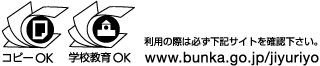  
この演習は、大学講義科目「画像工学」の講義資料として作成されています。  
このipynbファイルは、学校教育のための非営利目的利用を認めます。[https://www.bunka.go.jp/jiyuriyo](https://www.bunka.go.jp/jiyuriyo)  
この演習で使用している画像ファイル（imagefiles.zip、及び、imagefiles.zip 内の個々のファイル）については再配布を禁止します。